In [31]:
import pandas as pd
from pathlib import Path

# CSV_PATH = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results.csv")
# df_old = pd.read_csv(CSV_PATH)

# CSV_PATH_HYB = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results_hybrid.csv")
# df_hybrid = pd.read_csv(CSV_PATH_HYB)

# CSV_PATH_NEW = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results_answers_log_new_dataset_fixed2.csv")
# df_new = pd.read_csv(CSV_PATH_NEW)

CSV_PATH_NEW = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\graphrag\out\llm_judge_results_answers_log_new_dataset_rows_1_to_56_mild.csv")
df_new = pd.read_csv(CSV_PATH_NEW)





In [1]:
df_new["TP"] = (df_new["correctness_category"] == "TP").astype(int)
df_new["FP"] = (df_new["correctness_category"] == "FP").astype(int)
df_new["FN"] = (df_new["correctness_category"] == "FN").astype(int)
summary = (
    df_new.groupby("script", as_index=False)
      .agg(
          TP=("TP", "sum"),
          FP=("FP", "sum"),
          FN=("FN", "sum"),
      )
)
summary["Precision"] = summary["TP"] / (summary["TP"] + summary["FP"])
summary["Recall"]    = summary["TP"] / (summary["TP"] + summary["FN"])
summary["F1"]        = (
    2 * summary["Precision"] * summary["Recall"]
    / (summary["Precision"] + summary["Recall"])
)
summary_display = (
    summary
    .set_index("script")[["Precision", "Recall", "F1"]]
    .round(2)
)

print(summary_display.to_string())


NameError: name 'df_new' is not defined

In [33]:


counts = (
    df_new.groupby(["script", "correctness_error_severity"])
      .size()
      .unstack(fill_value=0)
)
#counts = counts.reindex(columns=["TP", "FP", "FN"], fill_value=0)
print(counts)




correctness_error_severity               high  low  medium
script                                                    
LLMGraph_Community_KG_Retriever             0    9       3
LLmaIndex_Community_Retriever               1   16       8
LLmaIndex_Hybrid_KG_Retriever_Rerank        1    5       3
SimpleKG_Community_KG_Retriever_Batched     1    5       4


In [32]:
counts = (
    df_new.groupby(["script", "correctness_category"])
      .size()
      .unstack(fill_value=0)
)
counts = counts.reindex(columns=["TP", "FP", "FN"], fill_value=0)
print(counts)




correctness_category                     TP  FP  FN
script                                             
LLMGraph_Community_KG_Retriever           0   0   3
LLmaIndex_Community_Retriever             7   1   1
LLmaIndex_Hybrid_KG_Retriever_Rerank      3   1   0
SimpleKG_Community_KG_Retriever_Batched   3   1   0


In [28]:


cols = ["script", "faithfulness_score", "faithfulness_1to5", "answer_relevance_score", "answer_relevance_1to5", "completeness_score" ,"completeness_1to5","correctness_coverage" ]
df_new = df_new[cols].copy()



summary = (
    df_new.groupby("script", as_index=False)
      .agg(
          Faith=("faithfulness_score", "mean"),
          Ans_Rel=("answer_relevance_score", "mean"),
          Cont_Rel=("completeness_score", "mean"),
          Faith2=("faithfulness_1to5", "mean"),
          Ans_Rel2=("answer_relevance_1to5", "mean"),
          Cont_Rel2=("completeness_1to5", "mean"),
          Corr =("correctness_coverage", "mean"),
          N=("script", "size"),
      )
)


summary_no_n = summary.drop(columns=["N"])


summary_no_n = summary_no_n.set_index("script").round(2)

print(summary_no_n.to_string())


                                         Faith  Ans_Rel  Cont_Rel  Faith2  Ans_Rel2  Cont_Rel2  Corr
script                                                                                              
LLMGraph_Community_KG_Retriever           0.61     0.67      0.38    3.33      3.67       2.50  0.39
LLmaIndex_Community_Retriever             0.35     0.76      0.39    2.36      4.00       2.56  0.62
LLmaIndex_Hybrid_KG_Retriever_Rerank      0.89     0.75      0.50    4.78      4.00       2.89  0.57
SimpleKG_Community_KG_Retriever_Batched   0.56     0.69      0.54    3.40      3.80       3.20  0.66


In [31]:
import numpy as np
import matplotlib.pyplot as plt

def pretty_heatmap(pivot_df, title, vmin=None, vmax=None, cmap="Greys"):
    """
    Matplotlib-only heatmap with:
    - nice layout
    - cell annotations
    - readable labels
    """
    dfp = pivot_df.copy()

    # Ensure consistent order (optional): keep as-is, but you can sort:
    # dfp = dfp.sort_index()

    data = dfp.values.astype(float)

    # If vmin/vmax not provided, autoscale to data range for better contrast
    finite = np.isfinite(data)
    if vmin is None:
        vmin = np.nanmin(data[finite]) if finite.any() else 0.0
    if vmax is None:
        vmax = np.nanmax(data[finite]) if finite.any() else 1.0
    if vmin == vmax:
        vmax = vmin + 1e-6

    fig_w = max(6, 1.2 * dfp.shape[1] + 3)     # width depends on #scripts
    fig_h = max(3.5, 0.55 * dfp.shape[0] + 1)  # height depends on #query_types

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(data, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)

    # Title
    ax.set_title(title, pad=12)

    # Axis ticks
    ax.set_yticks(np.arange(dfp.shape[0]))
    ax.set_yticklabels(dfp.index)

    ax.set_xticks(np.arange(dfp.shape[1]))
    ax.set_xticklabels(dfp.columns, rotation=0, ha="center")

    # Grid lines for cell separation (subtle)
    ax.set_xticks(np.arange(-.5, dfp.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, dfp.shape[0], 1), minor=True)
    ax.grid(which="minor", color="lightgray", linestyle="-", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Annotate cells with values
    for i in range(dfp.shape[0]):
        for j in range(dfp.shape[1]):
            val = data[i, j]
            if np.isfinite(val):
                # choose text color based on background brightness
                # (simple threshold on normalized value)
                norm = (val - vmin) / (vmax - vmin)
                text_color = "black" if norm < 0.65 else "white"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=10)
            else:
                ax.text(j, i, "—", ha="center", va="center", color="black", fontsize=10)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
    cbar.set_label("Mean score", rotation=90)

    plt.tight_layout()
    plt.show()


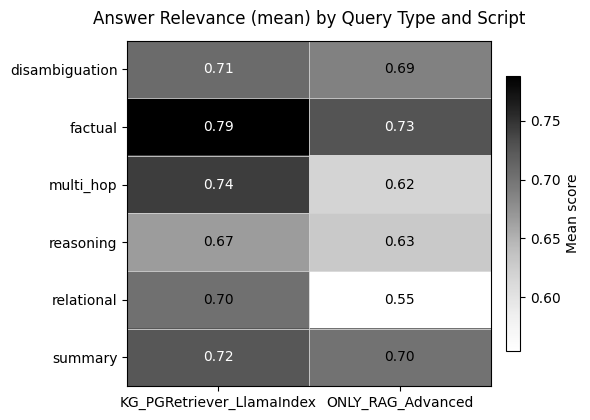

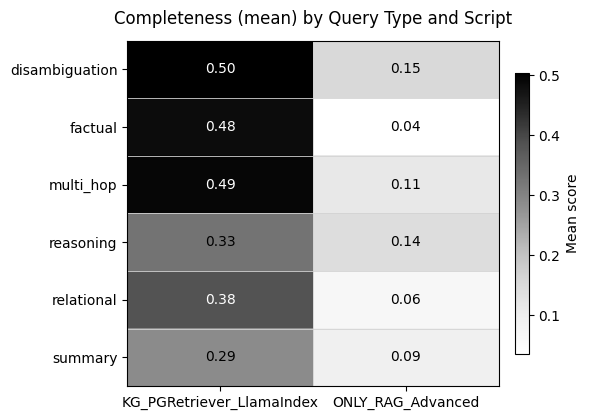

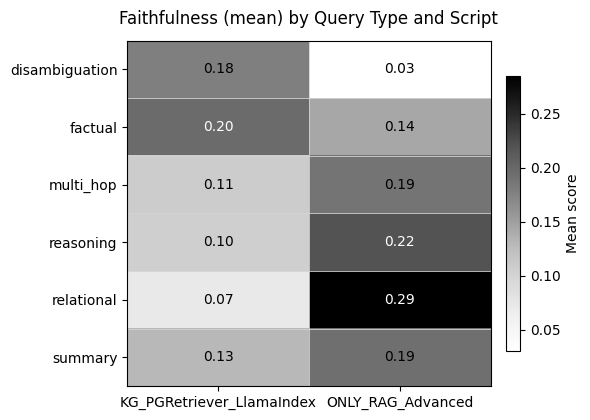

In [32]:
pretty_heatmap(rel_pivot,   "Answer Relevance (mean) by Query Type and Script")
pretty_heatmap(comp_pivot,  "Completeness (mean) by Query Type and Script")
pretty_heatmap(faith_pivot, "Faithfulness (mean) by Query Type and Script")


In [33]:
cat_counts = (
    df.groupby(["query_type", "script", "correctness_category"])
      .size()
      .rename("count")
      .reset_index()
)

cat_table = cat_counts.pivot_table(
    index=["query_type", "script"],
    columns="correctness_category",
    values="count",
    fill_value=0,
    aggfunc="sum"
).sort_index()

display(cat_table)


correctness_category                      fn  fp  tp
query_type     script                               
disambiguation KG_PGRetriever_LlamaIndex   1   6  15
               ONLY_RAG_Advanced          14   6   2
factual        KG_PGRetriever_LlamaIndex   7   7  15
               ONLY_RAG_Advanced          27   0   1
multi_hop      KG_PGRetriever_LlamaIndex   0  12  10
               ONLY_RAG_Advanced          14   8   0
reasoning      KG_PGRetriever_LlamaIndex   2  18   9
               ONLY_RAG_Advanced          16  12   1
relational     KG_PGRetriever_LlamaIndex   3  10  13
               ONLY_RAG_Advanced          24   0   2
summary        KG_PGRetriever_LlamaIndex   8   9   6
               ONLY_RAG_Advanced          13   9   1